In [1]:
import torch
import math
import einops
import itertools
import matplotlib.pyplot as plt

from omegaconf import OmegaConf

from experiment import Experiment
from utils.config import *
from utils.components import *
from utils.masking import BinaryMasking, ForecastMasking
from utils.einmask import EinMask
from utils.loss_fn import f_kernel_crps

/mnt/lustre/work/ludwig/jthuemmel54/miniforge3/envs/torch/lib/python3.13/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/mnt/lustre/work/ludwig/jthuemmel54/miniforge3/envs/torch/lib/python3.13/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadat

In [33]:
def task_confusion(grads: Dict[str, List[torch.Tensor]]) -> Dict[Tuple[str, str], float]:
    keys = list(grads.keys())
    confusion = {}
    for ki in keys:
        for kj in keys:
            if ki == kj:
                continue
            cos = sum(
                torch.nn.functional.cosine_similarity(gi.flatten(), gj.flatten(), dim=0)
                for gi, gj in zip(grads[ki], grads[kj])
            ) / len(grads[ki])
            confusion[(ki, kj)] = cos.item()
    return confusion

In [34]:
cfg_file = OmegaConf.load('mae.yaml')
config = MTMConfig.from_omegaconf(cfg_file.get("defaults", {}))
experiment = Experiment(config)
experiment.device = 'cuda:0'

In [35]:
experiment.model = experiment.create_model().to(experiment.device)

In [36]:
state_dict = torch.load('runs/2438503/best.pth', map_location=experiment.device)
experiment.model.load_state_dict(state_dict.get('model_state'))

<All keys matched successfully>

In [37]:
val_ds = experiment.godas_data()
val_dl = torch.utils.data.DataLoader(
        val_ds,
        batch_size=8,
        num_workers=0,
        drop_last=True,
        shuffle=False,
        pin_memory=True,
        )
lsm = torch.logical_not(val_ds.land_sea_mask.to(device=experiment.device, dtype=torch.bool))

In [38]:
def node_crps(ens: torch.Tensor, obs: torch.Tensor, mask: torch.BoolTensor):
        score = f_kernel_crps(observation=obs, ensemble=ens, fair = True)
        loss = (score * per_variable_weights)[mask].mean()
        return loss

def spectral_crps( ens: torch.Tensor, obs: torch.Tensor):
    w_v = per_variable_weights.mean(dim = (-1, -2, -3))
    with torch.amp.autocast(enabled = True, device_type = "cuda", dtype = torch.float32):
        e_fft = torch.fft.rfftn(ens.float(), dim = (-2, -3, -4)) #[B, V, ft, fh, fw, E]
        o_fft = torch.fft.rfftn(obs.float(), dim = (-1, -2, -3))
    score = f_kernel_crps(observation=o_fft, ensemble= e_fft, fair = True).mean(dim=(-1, -2, -3)) #[B, V]
    return (score * w_v).mean()

In [39]:
# weights = {
#         'temp_ocn_0a': 1.,
#         'temp_ocn_1a': 0.1,
#         'temp_ocn_3a': 0.1,
#         'temp_ocn_5a': 0.1,
#         'temp_ocn_8a': 0.1,
#         'temp_ocn_11a': 0.1,
#         'temp_ocn_14a': 0.1,
#         'tauxa': 0.01,
#         'tauya': 0.01,
#     }
# w = torch.as_tensor([weights.get(var, 1.) for var in experiment.data_cfg.variables], device = experiment.device)
# per_variable_weights = einops.repeat(w, f"(v vv) -> {experiment.world.field_pattern}", 
#                                                 **experiment.world.token_sizes, **experiment.world.patch_sizes)

per_variable_weights = torch.ones(experiment.world.field_shape, device=experiment.device)

In [62]:
batch = next(iter(val_dl))
batch = batch.to(experiment.device)
B = batch.size(0)
torch._functorch.config.donated_buffer = False

In [41]:
masking = BinaryMasking(experiment.world, event_cfg={}, rate_cfg={"stratify": True}).to(experiment.device)

event_cfgs = {
    'time': {"t": 0.1},
    'space': {"h": 0.1, "w": 0.1},
    'variable': {"v": 0.1},
    'mixed': {"v": 1., "t": 0.1, "h": None, "w": None},
}

rate_cfgs = {
    'src' : {'min': 1/3, 'max': 1/3},
    'tgt' : {'min': 2/3, 'max': 2/3},
}

frcst_rates = {
    'src' : {'min': 1/3, 'max': 1/3},
    'tgt' : {'min': 2/3, 'max': 2/3},
}

In [8]:

alphas = [0.1, 0.31, 3.1, None]
event_cfgs = [{"v": alphas[v], "t": alphas[t], 'prefix': alphas[p]}
    for (v, t, p) in itertools.permutations(range(len(alphas)), 3)]

print(len(event_cfgs))
event_cfgs

24


[{'v': 0.1, 't': 0.31, 'prefix': 3.1},
 {'v': 0.1, 't': 0.31, 'prefix': None},
 {'v': 0.1, 't': 3.1, 'prefix': 0.31},
 {'v': 0.1, 't': 3.1, 'prefix': None},
 {'v': 0.1, 't': None, 'prefix': 0.31},
 {'v': 0.1, 't': None, 'prefix': 3.1},
 {'v': 0.31, 't': 0.1, 'prefix': 3.1},
 {'v': 0.31, 't': 0.1, 'prefix': None},
 {'v': 0.31, 't': 3.1, 'prefix': 0.1},
 {'v': 0.31, 't': 3.1, 'prefix': None},
 {'v': 0.31, 't': None, 'prefix': 0.1},
 {'v': 0.31, 't': None, 'prefix': 3.1},
 {'v': 3.1, 't': 0.1, 'prefix': 0.31},
 {'v': 3.1, 't': 0.1, 'prefix': None},
 {'v': 3.1, 't': 0.31, 'prefix': 0.1},
 {'v': 3.1, 't': 0.31, 'prefix': None},
 {'v': 3.1, 't': None, 'prefix': 0.1},
 {'v': 3.1, 't': None, 'prefix': 0.31},
 {'v': None, 't': 0.1, 'prefix': 0.31},
 {'v': None, 't': 0.1, 'prefix': 3.1},
 {'v': None, 't': 0.31, 'prefix': 0.1},
 {'v': None, 't': 0.31, 'prefix': 3.1},
 {'v': None, 't': 3.1, 'prefix': 0.1},
 {'v': None, 't': 3.1, 'prefix': 0.31}]

In [17]:
vs = [0.31, None]
ts = [0.31, None]
hws = [0.5, 3.1, None]
ps = [0.1, 3.1, None]

event_cfgs = {}
for v, t, hw, p in itertools.product(vs, ts, hws, ps):
    event_cfgs[f'mixed_{v}_{t}_{hw}_{p}'] = {"v": v, "t": t, "h": hw, "w": hw, 'prefix': p}

event_list = [{"v": v, "t": t, "h": hw, "w": hw, 'prefix': p} for v, t, hw, p in itertools.product(vs, ts, hws, ps) ]
#event_cfgs = {f"prior_{i}": {'v':1.,'t': 0.5, 'prefix': 0.5} for i in range(8)}

# alphas = [0.1, 0.31, 1., None]
# event_cfgs = {
#     f"{alphas[v]}, {alphas[t]}, {alphas[hw]}, {alphas[p]}" : {"v": alphas[v], "t": alphas[t], "h": alphas[hw], "w": alphas[hw], 'prefix': alphas[p]}
#     for (v, t, hw, p) in itertools.permutations(range(len(alphas)), len(experiment.world.layout))
# }

# event_cfgs = {
#     f'mixed_{i}': {'t': 0.31, 'prefix': 1.} for i in range(16)
# }

# event_cfgs.update({
#     'time': {"t": 1e-3},
#     'space': {"h": 1e-3, "w": 1e-3},
#     'variable': {"v": 1e-3},
#     'frcst': {'prefix': 1e-3},
# })

In [18]:
print(len(event_list))
print(event_list)
sum([exists(cfg.get('prefix')) for cfg in event_list])

36
[{'v': 0.31, 't': 0.31, 'h': 0.5, 'w': 0.5, 'prefix': 0.1}, {'v': 0.31, 't': 0.31, 'h': 0.5, 'w': 0.5, 'prefix': 3.1}, {'v': 0.31, 't': 0.31, 'h': 0.5, 'w': 0.5, 'prefix': None}, {'v': 0.31, 't': 0.31, 'h': 3.1, 'w': 3.1, 'prefix': 0.1}, {'v': 0.31, 't': 0.31, 'h': 3.1, 'w': 3.1, 'prefix': 3.1}, {'v': 0.31, 't': 0.31, 'h': 3.1, 'w': 3.1, 'prefix': None}, {'v': 0.31, 't': 0.31, 'h': None, 'w': None, 'prefix': 0.1}, {'v': 0.31, 't': 0.31, 'h': None, 'w': None, 'prefix': 3.1}, {'v': 0.31, 't': 0.31, 'h': None, 'w': None, 'prefix': None}, {'v': 0.31, 't': None, 'h': 0.5, 'w': 0.5, 'prefix': 0.1}, {'v': 0.31, 't': None, 'h': 0.5, 'w': 0.5, 'prefix': 3.1}, {'v': 0.31, 't': None, 'h': 0.5, 'w': 0.5, 'prefix': None}, {'v': 0.31, 't': None, 'h': 3.1, 'w': 3.1, 'prefix': 0.1}, {'v': 0.31, 't': None, 'h': 3.1, 'w': 3.1, 'prefix': 3.1}, {'v': 0.31, 't': None, 'h': 3.1, 'w': 3.1, 'prefix': None}, {'v': 0.31, 't': None, 'h': None, 'w': None, 'prefix': 0.1}, {'v': 0.31, 't': None, 'h': None, 'w': 

24

In [112]:
tasks = {}
for key, task in event_cfgs.items():
    masking.event_cfg = task
    P = masking.event_prior(B)
    M = masking.binary_topk_(P, 1200)
    tasks[(key, "src")] = M
    tasks[(key, "tgt")] = M.logical_not()

In [113]:
task_gradients = {}
keys = list(event_cfgs.keys())
        
for key in keys:
    src, tgt = tasks[(key,'src')], tasks[(key,'tgt')]
    mask = torch.logical_and(experiment.mask_to_field(tgt), lsm)
    with torch.amp.autocast(device_type="cuda"):
        #with torch.no_grad(): prediction = experiment.model(batch, src, members = 4)
        prediction = experiment.model(batch, src, members = 4)
        prediction = prediction * lsm[..., None]

    spectral_loss = spectral_crps(prediction, batch) * 0.01
    node_loss = node_crps(prediction, batch, mask)
    mae_loss = (prediction.mean(-1) - batch).abs()[mask].mean()
    
    experiment.model.zero_grad()
    (spectral_loss + node_loss).backward(retain_graph = False)
    task_gradients[key] = [m.grad.clone() for m in experiment.model.parameters() if m.requires_grad]

    # experiment.model.zero_grad()
    # spectral_loss.backward(retain_graph = True)
    # task_gradients[(key,'spectral')] = [m.grad.clone() for m in experiment.model.parameters() if m.requires_grad]

    # experiment.model.zero_grad()
    # node_loss.backward(retain_graph = False)
    # task_gradients[(key, 'node')] = [m.grad.clone() for m in experiment.model.parameters() if m.requires_grad]

    # experiment.model.zero_grad()
    # mae_loss.mean().backward(retain_graph = False)
    # task_gradients[(key,'mae')] = [m.grad.clone() for m in experiment.model.parameters() if m.requires_grad]


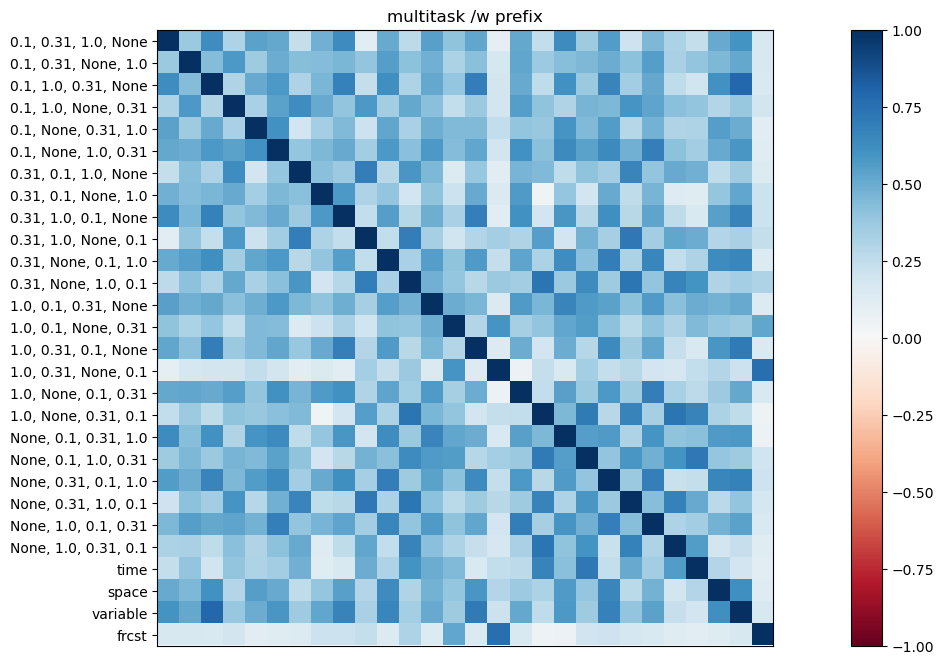

In [114]:

confusion = task_confusion(task_gradients)
keys = list(task_gradients.keys())

matrix = torch.zeros((len(keys), len(keys)))
for i, ki in enumerate(keys):
    for j, kj in enumerate(keys):
        matrix[i, j] = confusion.get((ki, kj), 1.0)  # diagonal = 1

fig, ax = plt.subplots(figsize = (20, 8))
im = ax.imshow(matrix, vmin=-1, vmax=1, cmap='RdBu')
ax.set_xticks([])
ax.set_yticks(range(len(keys))); ax.set_yticklabels(keys)
plt.colorbar(im)
plt.title('multitask /w prefix')
plt.show()

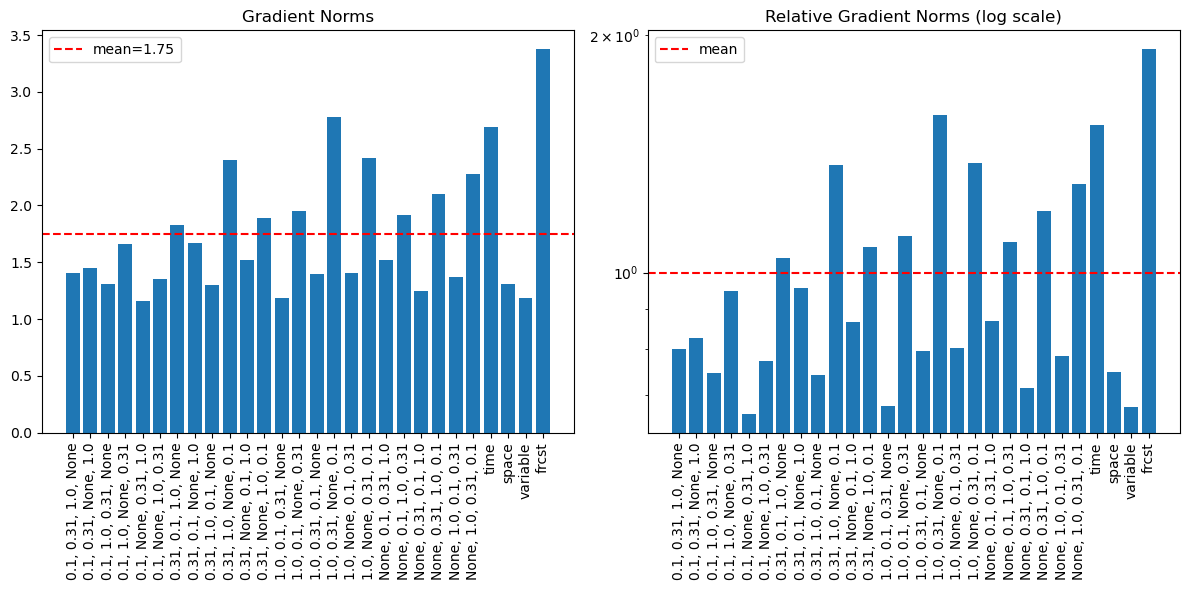

In [115]:
norms = {
    key: sum(g.norm().item() ** 2 for g in grads) ** 0.5
    for key, grads in task_gradients.items()
}

keys = list(norms.keys())
values = list(norms.values())
mean_norm = sum(values) / len(values)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# absolute norms
axes[0].bar(range(len(keys)), values)
axes[0].axhline(mean_norm, color='r', linestyle='--', label=f'mean={mean_norm:.2f}')
axes[0].set_xticks(range(len(keys)))
axes[0].set_xticklabels(keys, rotation=90)
axes[0].set_title('Gradient Norms')
axes[0].legend()

# relative norms (log scale to see variance clearly)
axes[1].bar(range(len(keys)), [v / mean_norm for v in values])
axes[1].axhline(1.0, color='r', linestyle='--', label='mean')
axes[1].set_xticks(range(len(keys)))
axes[1].set_xticklabels(keys, rotation=90)
axes[1].set_yscale('log')
axes[1].set_title('Relative Gradient Norms (log scale)')
axes[1].legend()

plt.tight_layout()


In [83]:
import torch
import math
import einops
import itertools
import matplotlib.pyplot as plt

from omegaconf import OmegaConf

from experiment import Experiment
from utils.config import *
from utils.components import *


In [95]:
import einops
import torch

from einops.layers.torch import *
from utils.config import *
from utils.components import *
from torch.nn.functional import softplus

class EinMask(torch.nn.Module):
    def __init__(self, network: NetworkConfig, world: WorldConfig):
        super().__init__()
        self.network = network
        self.world = world

        # Encoder
        self.tokenizer =  EinMix(
            f'b {world.field_pattern} -> b ({world.token_pattern}) di', 
            weight_shape= f'v {world.patch_pattern} di', 
            **world.patch_sizes, **world.token_sizes, di = network.dim_in
            )
        
        self.positions = torch.nn.Parameter(torch.zeros(1, world.num_tokens, network.dim_in))
        self.mask_token = torch.nn.Parameter(torch.zeros(1, 1, network.dim_in))
    
        self.encoder = torch.nn.ModuleList([
              TransformerBlock(dim= network.dim_in) for _ in range(default(network.num_read_blocks, 1))
              ])
        
        # Predictor
        self.predictor = torch.nn.Sequential(
            torch.nn.Linear(network.dim_in, network.dim, bias = False),
            *[TransformerBlock(dim= network.dim) for _ in range(default(network.num_compute_blocks, 1))],
            torch.nn.Linear(network.dim, network.dim_in, bias = False)
        )

        # weight initialization
        self.apply(self.base_init)

        # maybe compile
        self.predictor.compile()

    @staticmethod
    def base_init(m: torch.nn.Module):
        # linear
        if isinstance(m, torch.nn.Linear):
            torch.nn.init.trunc_normal_(m.weight, std = 0.02)
            if m.bias is not None:
                torch.nn.init.zeros_(m.bias)
        # embedding
        elif isinstance(m, torch.nn.Embedding):
            torch.nn.init.trunc_normal_(m.weight, std = 0.02)
        # einmix
        elif isinstance(m, EinMix):
            torch.nn.init.trunc_normal_(m.weight, std = 0.02)
            if m.bias is not None:
                torch.nn.init.zeros_(m.bias)
        # explicit parameters
        elif isinstance(m, EinMask):
            torch.nn.init.trunc_normal_(m.mask_token, std = 0.02)
            torch.nn.init.trunc_normal_(m.positions, std = 0.02)
    
    def forward(self, 
                fields: torch.FloatTensor, 
                visible: torch.BoolTensor, 
                ) -> torch.FloatTensor:
        src = self.encode(fields, visible)
        tgt = self.predict(src, visible)
        return src, tgt

    def encode(self, 
                fields: torch.FloatTensor, 
                visible: torch.BoolTensor, 
                ) -> torch.FloatTensor:
        # map fields to tokens and add position codes
        tokens = self.tokenizer(fields) + self.positions

        # encode visible tokens only
        src = einops.rearrange(tokens[visible], '(b n) d -> b n d', b = tokens.size(0), d = tokens.size(-1))
        for read in self.encoder:
            src = read(src)

        return src

    def predict(self, 
                src: torch.FloatTensor, 
                visible: torch.BoolTensor, 
                ) -> torch.FloatTensor:
        # pad with mask tokens
        tgt = torch.masked_scatter(
            input = (self.mask_token + self.positions).type_as(src), 
            mask = visible[..., None],
            source = src
            )
        
        # predict masked locations
        tgt = self.predictor(tgt)

        return tgt
    

In [96]:

cfg_file = OmegaConf.load('mae.yaml')
config = MTMConfig.from_omegaconf(cfg_file.get("defaults", {}))

In [97]:
B, K = 2, 256
device = 'cuda'
jepa = EinMask(config.model, config.world).to(device)
m_all = torch.ones((B, config.world.num_tokens), dtype= torch.bool, device= device)
m = torch.rand((B, config.world.num_tokens), device= device).log().argsort().argsort().lt(K)
x = torch.randn((B, *config.world.field_shape), device= device)


In [98]:
print(f'encoder: {count_parameters(jepa) - count_parameters(jepa.predictor):,}, predictor: {count_parameters(jepa.predictor):,}')

encoder: 49,743,104, predictor: 6,491,392


In [146]:
pr = lambda c: c.trace().pow(2) / c.pow(2).sum()
D = config.model.dim_in

with torch.autocast(device_type=device, dtype=torch.half):
    z = jepa.encode(x, m)
    z_hat = jepa.predict(z, m)

    with torch.no_grad():
        tgt = jepa.encode(x, m_all)

        combined = einops.rearrange([tgt, z_hat], 'two b n d -> (two d) b n')[:, m]
        cov = torch.cov(combined)  # (2D, 2D)
        pr_ema_ema  = pr(cov[:D, :D])
        pr_hat_hat = pr(cov[D:, D:])
        pr_ema_hat = pr(cov[:D, D:])

        
    loss = (tgt - z_hat).abs()[m.logical_not()].mean()

loss.backward()

In [147]:
print(f'ema: {pr_ema_ema.item()}, hat: {pr_hat_hat.item()}, cross: {pr_ema_hat.item()}')

ema: 277.28436279296875, hat: 123.14082336425781, cross: 0.0015376051887869835


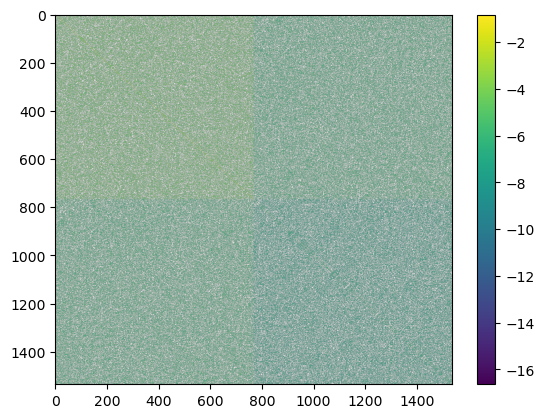

In [148]:
plt.imshow(cov.cpu().log(), aspect ='auto')
plt.colorbar()

In [90]:
log_alphas = torch.logspace(-1, 1, 5)
B = 10000
T = config.world.token_sizes['t']
K = int(0.15 * config.world.num_tokens)
cs = []
for alpha in log_alphas:
    u = torch.rand((B, config.world.num_tokens), device= device).log()
    #t = torch.rand((B,T), device= device).log().div(alpha).sort().values
    t = torch.linspace(0, 1,T, device= device).expand(B, -1).log().div(alpha)
    u += einops.repeat(t, f'b t -> b ({config.world.token_pattern})', **config.world.token_sizes)

    # v = torch.rand((B, config.world.token_sizes['v']), device= device).log().div(3.1)
    # u += einops.repeat(v, f'b v -> b ({config.world.token_pattern})', **config.world.token_sizes)

    indices = u.topk(K, sorted=False).indices
    coordinates = torch.unravel_index(indices, config.world.token_shape)
    counts = torch.bincount(coordinates[1].view(-1), minlength= T)
    cs.append(counts / (K * B))
cs = torch.stack(cs)

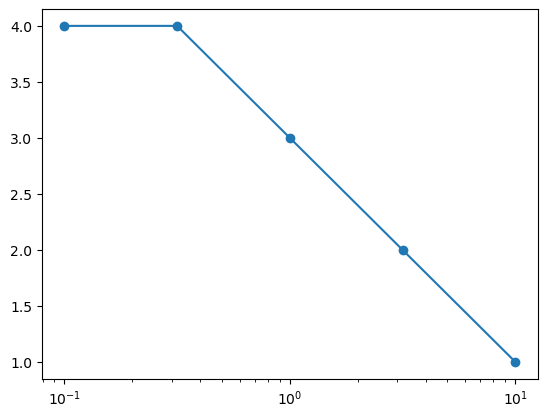

In [91]:
plt.semilogx(log_alphas, T - cs.gt(1e-3).float().sum(-1), 'o-')


In [ ]:
import einops
import torch

from einops.layers.torch import *
from utils.config import *
from utils.components import *
from torch.nn.functional import softplus

class ScatterMask(torch.nn.Module):
    def __init__(self, dim: int):
        super().__init__()
        self.weight = torch.nn.Parameter(torch.zeros(dim))
        torch.nn.init.trunc_normal_(self.weight, std = 0.02)
    
    @torch.compiler.disable()
    def forward(self, x: torch.Tensor, visible: torch.BoolTensor):
        # copies visible elements into a tensor full of mask tokens
        return torch.masked_scatter(
            input = self.weight.type_as(x), 
            mask = visible[..., None],
            source = x)
    
class GatherMask(torch.nn.Module):   
    @torch.compiler.disable()
    def forward(self, x: torch.Tensor, visible: torch.BoolTensor):
        # selects visible elements from a tensor and returns them in the correct shape
        return einops.rearrange(x[visible], '(b k) ... -> b k ...', b = x.size(0))

class EinMask(torch.nn.Module):
    def __init__(self, network: NetworkConfig, world: WorldConfig):
        super().__init__()
        self.network = network
        self.world = world

        DI = network.dim_in
        DP = network.dim
        DO = network.dim_out

        # Encoder
        self.fields_to_encoder =  EinMix(
            f'b {world.field_pattern} -> b ({world.token_pattern}) di', 
            weight_shape= f'v {world.patch_pattern} di', 
            bias_shape = f'({world.token_pattern}) di',
            **world.patch_sizes, **world.token_sizes, di = DI
            )
        self.encoder_mask = GatherMask()
        self.encoder = torch.nn.ModuleList([
              TransformerBlock(dim= DI) for _ in range(default(network.num_read_blocks, 1))
              ])
        
        # Predictor
        self.to_predictor = EinMix('b n di -> b n dp', 'dp di', 'n dp', n = world.num_tokens, di = DI, dp = DP)
        self.to_prediction = EinMix('b n dp -> b n di', 'di dp', di = DI, dp = DP)
        self.predictor_mask = ScatterMask(DP)
        self.predictor = torch.nn.ModuleList([
              TransformerBlock(dim= DP) for _ in range(default(network.num_compute_blocks, 1))
              ])
        
        # Decoder
        if network.kwargs.get('has_decoder', True):
            self.decoder_to_fields = FieldDecoder(network, world)
            self.predictor_to_bottleneck = EinMix('b n di -> b n db', 'db di', 'n db', 
                                                n = world.num_tokens, di = network.dim_in, db = DO * 2)
            self.bottleneck = TransformerBlock(dim = DO * 2, num_heads=network.num_decoder_heads)
            self.decoder = torch.nn.ModuleList([
                TransformerBlock(dim=network.dim_out) for _ in range(default(network.num_write_blocks, 1))
                ])

        # weight initialization
        self.apply(self.base_init)

    @staticmethod
    def base_init(m: torch.nn.Module):
        # linear
        if isinstance(m, torch.nn.Linear):
            torch.nn.init.trunc_normal_(m.weight, std = 0.02)
            if m.bias is not None:
                torch.nn.init.zeros_(m.bias)
        # embedding
        elif isinstance(m, torch.nn.Embedding):
            torch.nn.init.trunc_normal_(m.weight, std = 0.02)
        # einmix
        elif isinstance(m, EinMix):
            torch.nn.init.trunc_normal_(m.weight, std = 0.02)
            if m.bias is not None:
                torch.nn.init.zeros_(m.bias)
    
    def forward(self, 
                fields: torch.FloatTensor, 
                visible: torch.BoolTensor, 
                members: Optional[int] = None, 
                rng: Optional[torch.Generator] = None,
                ) -> Tuple[torch.FloatTensor, torch.FloatTensor]:
        latents = self.encode(fields, visible)
        latents = self.predict(latents, visible)
        ensemble = self.decode(latents, members, rng) if self.network.kwargs.get('has_decoder', True) else None
        return ensemble, latents
    
    def encode(self,
               fields: torch.FloatTensor, 
               visible: torch.BoolTensor, 
               ) -> torch.FloatTensor:
        tokens = self.fields_to_encoder(fields)
        x = self.encoder_mask(tokens, visible)
        for read in self.encoder:
            x = read(x)
        return x
    
    def predict(self,
               latents: torch.FloatTensor, 
               visible: torch.BoolTensor, 
               ) -> torch.FloatTensor:
        x = self.predictor_mask(latents, visible)
        x = self.to_predictor(x)
        for compute in self.predictor:
            x = compute(x)
        x = self.to_prediction(x)
        return x
    
    def decode(self, 
               latents: torch.FloatTensor,
               members: Optional[int] = None, 
               rng: Optional[torch.Generator] = None
               ) -> torch.FloatTensor:
        x = self.predictor_to_bottleneck(latents)
        x = self.bottleneck(x)
        mu, sigma = einops.repeat(x, 'b n (two d) -> two (b e) n d', e = default(members, 1), two = 2)
        x = mu + torch.randn_like(sigma, generator = rng) * softplus(sigma)
        for write in self.decoder:
            x = write(x)
        fields = self.decoder_to_fields(x)
        fields = einops.rearrange(fields, "(b e) ... -> b ... e", e = default(members, 1))
        return fields

In [6]:
import torch
import einops
import numpy as np
import matplotlib.pyplot as plt

In [7]:
B, N, D, E = 4, 120, 16, 8
ens = torch.randn((B, N, E))
obs = torch.randn((B, N))

mask = torch.rand((B, N)).log().argsort(descending=True).argsort().lt(56)

In [18]:
zero_mask = torch.zeros_like(mask)

x = einops.rearrange(ens[zero_mask], '(b n) d -> b n d', b = B)
x = torch.cat([x, ens], dim = 1)

In [19]:
x.shape

torch.Size([4, 120, 8])